## Middleware

More tightly controled on what happens in the agent

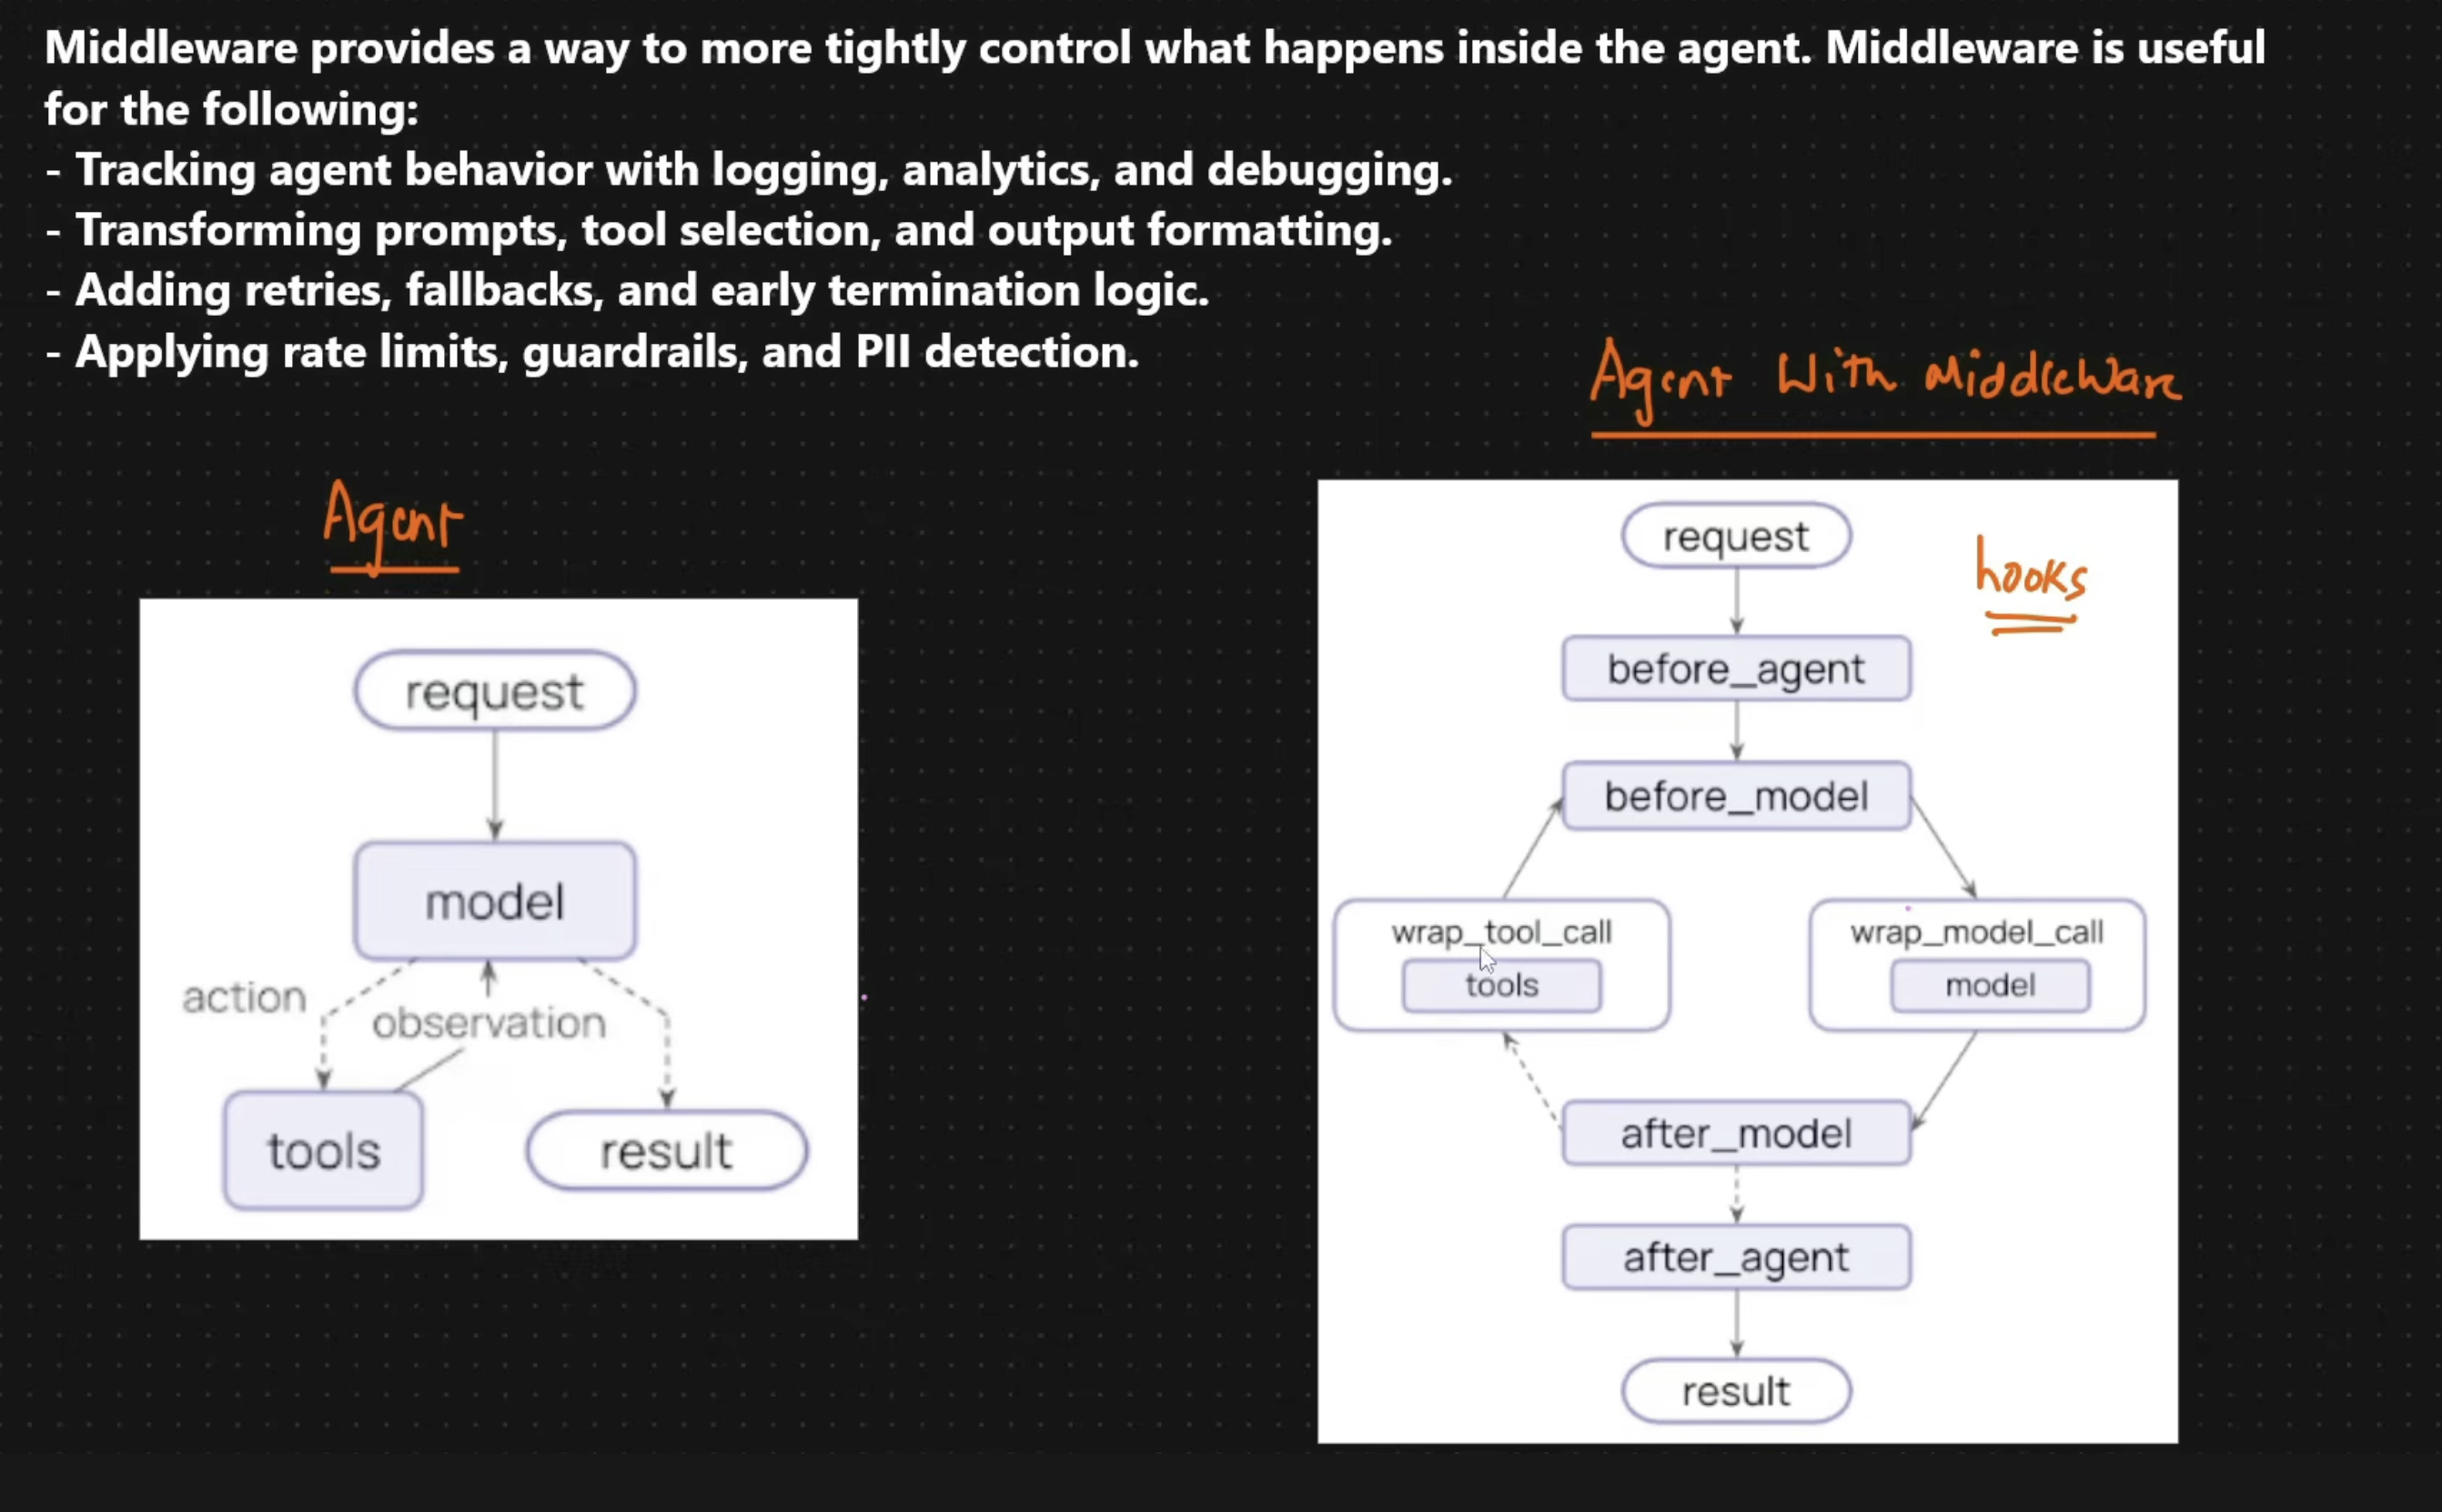

## Summarization Middleware

It automatically summarizatuion when reaching the token limit is reached  , preserving the latest messages and summarizing the older messages 

In [34]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver 
from langchain_core.messages import SystemMessage , HumanMessage

In [ ]:
agent = create_agent(
    model = "google_genai:gemini-2.5-flash",
    checkpointer=InMemorySaver(), 
    middleware=[
        SummarizationMiddleware(
        model = "google_genai:gemini-1.5-flash",
        trigger = ("messages" ,5),
        keep=("messages",2))
        
    ]
)

In [22]:
config = {"configurable": {"thread_id":"test-1"}}

In [23]:
questions = [
    "What is 2*2", 
    "What is 15-6", 
    "What is 8 + 7"
]

for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]} , config)
    print(f"Messages {response}")
    print(f"Messages {len(response['messages'])}")

Messages {'messages': [HumanMessage(content='What is 2*2', additional_kwargs={}, response_metadata={}, id='634686c5-5ade-4be1-b052-a475e43e49f7'), AIMessage(content='2 * 2 = 4', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e7824-bace-7042-9a61-84b4bcf76f1e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 23, 'total_tokens': 30, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 16}})]}
Messages 2
Messages {'messages': [HumanMessage(content='What is 2*2', additional_kwargs={}, response_metadata={}, id='634686c5-5ade-4be1-b052-a475e43e49f7'), AIMessage(content='2 * 2 = 4', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e7824-bace-7042-9a61-84b4bcf76f1e-0', tool_calls=

In [ ]:

@tool
def places(city: str):
    """Give the list of the places a tourist must visit in a given city """
    return f"""Places to visit {city}:
    Agra : Taj Mahal
    Paris : Eiffel Tower
    Dubai : Burj Khalifa
    Malaysia : Genting Islands
    """

from langchain_core.tools import tool

agent = create_agent(
    model = "google_genai:gemini-2.5-flash",
    tools = [places],
    checkpointer=InMemorySaver(), 
    middleware=[
        SummarizationMiddleware(
        model = "google_genai:gemini-1.5-flash",
        trigger = ("tokens" ,500), # trigger = ("faction" , 0.0005) it is a fraction percentage of the model context
        keep=("tokens",200)) # keep=("fraction",0.002))
        
    ]
)

In [ ]:
questions = [
    "Agra", 
    "Malaysia", 
    "Paris", 
    "Dubai"
]

def count_tokens(messages):
    token_sum = sum(len(str(m.content)) for m in messages)
    return token_sum //4


for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]} , config)
    token = count_tokens(response["messages"])
    print(f"{q}: token{token} , {len(response['messages'])} messages ")
    print(f"{response['messages']}")


Agra: token173 , 4 messages 
[HumanMessage(content='Agra', additional_kwargs={}, response_metadata={}, id='fde33129-86aa-4be6-941b-c480de2e01c6'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'places', 'arguments': '{"city": "Agra"}'}, '__gemini_function_call_thought_signatures__': {'fab17a9b-c204-41c3-b433-d2b5167171c6': 'CpECAQw51sdE5uqZoyZgaa1DX3ABvbcRc5Km6rCC1Kex/71MaQoWBuC2zJ9NRHZOWgxJKygfKqZWXUCm4OeDLp+8wZyvI5XnG18tgMm7S8nsGOw4ZGGXvZ3yrzHV6fg0HLD8jvhw80WARU5UgL3s8oaDocu5nGySsO6wcGYf1PQsXly4rNv0mVDb1C8CWUvSgxkixblBeJLYguOel5r7S/dkwJzPZrwGXk7tv2TdvUhEorD4vom2Pq3tbj+FW4OYIGgnl9oj2n4a0/mJ/O9HHRCMmVTG0RM1Quv2JgAR5YDRFcsi46MNtvh7pwRQiQdc7ltM900v9AIjkDdBOJ5GHrpG2iGiCnTbKrnVw3V/ZxiHOq22'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e7832-94da-7812-bd5b-05f528c5a611-0', tool_calls=[{'name': 'places', 'args': {'city': 'Agra'}, 'id': 'fab17a9b-c204-41c3-b433-d2b5

KeyboardInterrupt: 

## Human in the Loop 

it waits for the human approval before proceeding for any changes 

In [30]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import HumanInTheLoopMiddleware


def read_the_email (email_id : str):
    "moock the function of reading the email id"
    return f"The email id is {email_id}"

def send_the_email(recepient : str , subject : str , body : str):
    "Mock the function to send an email"
    return f"Email send to recepient{recepient} with subject{subject} and body {body}"


In [ ]:
agent = create_agent(
    model = "google_genai:gemini-2.5-flash", 
    tools =[read_the_email , send_the_email],
    checkpointer=InMemorySaver(),
    middleware=[HumanInTheLoopMiddleware(interrupt_on = 
                                         {"send_the_email": {"allowed_decisions":["approve", "edit", "reject"]}, 
                                          "read_the_email" : False})]
)

In [ ]:
config = {"configurable":{"thread_id":"test-1"}}
result = agent.invoke({"messages" : [HumanMessage(content = "SEnd an email to karp@gmaiul.com with subject 'hello' and with body 'Hope you are doing welll'")]},config=config)



In [43]:
result

{'messages': [HumanMessage(content="SEnd an email to karp@gmaiul.com with subject 'hello' and with body 'Hope you are doing welll'", additional_kwargs={}, response_metadata={}, id='6f7f115a-2aeb-4bdf-8364-c8d843c3f9c3'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'send_the_email', 'arguments': '{"recepient": "karp@gmaiul.com", "body": "Hope you are doing welll", "subject": "hello"}'}, '__gemini_function_call_thought_signatures__': {'692428c8-cb0c-4d3a-bc96-adcc7a5c23ec': 'CoICAQw51scRHz10i2LQueD/cb/BMz8fh3Zv9+TRpnutUHmMAXsgxBYnhE9Rh65o+FGA86I2L5i1el8jX29VhWyxxXTbiFzZ5MpM3Wpb6PWYjal3DvuFGn2y8LvgcmydNAmfVx4AdwbotcfEgrQnxR+y+FvMOG+Bwdi+S1FSTeok6B2q98727rGHcRQixKIWikTB8Fji3QCwTG3WK9phJ5qxXWsihDLE1tl09RR5JIfLwolZwImIiB++51PjGHeIe1+LpzXeGxqsyGGPCzbKoi2DoaFibKnQY8aI8FwopaZKDRFRzJs/QAop52RC6VECBqPDv1Jk/yww7zUwUmVIuDFj6r7H'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_ru

In [49]:

from langgraph.types import Command


if '__interrupt__' in result:
    print("Paused for approval")

    result = agent.invoke(
        Command (
            resume = {
                "decisions":
                [{
                    "type":"approve"
                }]
            }
        ), config = config
    )

print(result["messages"][-1].content)

Paused for approval


ValueError: Number of human decisions (2) does not match number of hanging tool calls (1).